In [6]:
# Cell 1
import os
print(os.getcwd())
print(os.listdir('src'))

C:\Users\uzzaa\psx-censored-garch
['.ipynb_checkpoints', 'bands.py', 'loader.py', 'universe.py', '__pycache__']


In [7]:
# Cell 2
import sys
import pandas as pd
sys.path.append('src')
from loader import load
from datetime import date

In [8]:
# Cell 3 — full KSE-100, for tier selection
kse100_tickers = [
    'HBLGF', 'FHAM', 'PGLC', 'ENGROH', 'PSX', 'DHP',
    'UBL', 'BAHL', 'BAFL', 'BOP', 'FABL', 'MEBL', 'HBL', 'HMB', 'MCB',
    'NBP', 'SCBPL', 'AKBL', 'ABL', 'AICL', 'DCR', 'TPLRF1',
    'GADT', 'YOUW', 'NML', 'MEHT', 'KTML', 'ILP', 'BNWM', 'IBFL', 'JDWS',
    'LUCK', 'DGKC', 'BWCL', 'FCCL', 'KOHC', 'CHCC', 'MLCF', 'POWER', 'PIOC',
    'PAKT', 'ATRL', 'CNERGY', 'HUBC', 'KAPCO', 'KEL',
    'PSO', 'APL', 'SNGP', 'SSGC', 'OGDC', 'MARI', 'POL', 'PPL',
    'ISL', 'INIL', 'MTL', 'INDU', 'SAZEW', 'ATLH', 'HCAR', 'GAL', 'GHNI',
    'THALL', 'PAEL', 'PIBTL', 'SYS', 'AIRLINK', 'PTC', 'TRG', 'HUMNL',
    'FFC', 'EFERT', 'AHCL', 'FATIMA',
    'SEARL', 'AGP', 'GLAXO', 'ABOT', 'CPHL', 'HALEON', 'HINOON',
    'LCI', 'LOTCHEM', 'PKGS', 'SSOM', 'SRVI',
    'NESTLE', 'FAUF', 'MUREB', 'COLG', 'NATF', 'RMPL', 'UPFL',
    'TGL', 'GHGL', 'PSEL', 'PABC', 'SHFA', 'JVDC',
]
print(len(kse100_tickers))

100


In [9]:
# Cell 4 — this step is done, kept for reference only, don't re-run unless needed
# all_data = {}
# failed = []
# for t in kse100_tickers:
#     try:
#         all_data[t] = load(t, start=date(2026, 7, 1), end=date(2026, 8, 31))
#     except Exception as e:
#         failed.append((t, str(e)))
# print(f"Fetched: {len(all_data)} / Failed: {len(failed)}")

In [10]:
# Cell 5 — universe is already finalized, load it fresh from the fixed file
import universe
from universe import UNIVERSE
print(len(UNIVERSE), UNIVERSE)
assert 'SEARL' not in UNIVERSE, "SEARL still in universe.py — go fix the file"
assert 'AGP' in UNIVERSE, "AGP missing — go fix the file"

30 ['MEBL', 'OGDC', 'FFC', 'LUCK', 'MARI', 'HUBC', 'ABOT', 'NESTLE', 'ATLH', 'UBL', 'FABL', 'EFERT', 'FCCL', 'NML', 'SNGP', 'SYS', 'AGP', 'ISL', 'AICL', 'TGL', 'AHCL', 'CNERGY', 'HUMNL', 'KAPCO', 'KEL', 'LOTCHEM', 'PIBTL', 'POWER', 'SSGC', 'YOUW']


In [11]:
# Cell 6 — the real pull: full history for the final 30
full_data = {}
for t in UNIVERSE:
    full_data[t] = load(t, start=date(2015, 1, 1), end=date(2026, 8, 31))
    print(t, len(full_data[t]), "rows")

MEBL 2866 rows
OGDC 2891 rows
FFC 2891 rows
LUCK 2886 rows
MARI 2891 rows
HUBC 2891 rows
ABOT 2821 rows
NESTLE 2259 rows
ATLH 2582 rows
UBL 2891 rows
FABL 2887 rows
EFERT 2891 rows
FCCL 2891 rows
NML 2891 rows
SNGP 2891 rows
SYS 2855 rows
AGP 2096 rows
ISL 2890 rows
AICL 2861 rows
TGL 2889 rows
AHCL 2733 rows
CNERGY 2891 rows
HUMNL 2887 rows
KAPCO 2891 rows
KEL 2891 rows
LOTCHEM 2891 rows
PIBTL 2891 rows
POWER 2891 rows
SSGC 2891 rows
YOUW 2810 rows


In [12]:
print(full_data['AGP'].index.min(), full_data['AGP'].index.max())

2018-03-05 00:00:00 2026-08-31 00:00:00


In [13]:
with open('src/bands.py') as f:
    print(f.read())

# src/bands.py â€” PSX scrip-level circuit breakers, 2015-2026
# Rule: limit_rs = max(pct * prev_close, FLOOR)
#
# SOURCING STATUS:
#   2020 steps  - PSX notice (psx.com.pk/psx/files/?file=141446-1.pdf)
#   2024 steps  - PSX notice via Mettis/DDC; VERIFY against primary
#   pre-2020    - PROVISIONAL. post-2008 5% regime, no primary source yet
#   Mar-Aug 20  - UNVERIFIED whether schedule held through COVID crash
#
# The floor is why cheap stocks get wider effective bands: at 5%,
# anything under Rs.20 is governed by the Re.1 floor, not the percentage.

import numpy as np
import pandas as pd

FLOOR = 1.0

SCHEDULE = [
  ("2015-01-01", 0.050),  # provisional
  ("2020-01-20", 0.055),
  ("2020-02-04", 0.060),
  ("2020-02-19", 0.065),
  ("2020-03-05", 0.070),
  ("2020-03-20", 0.075),
  ("2024-05-27", 0.080),
  ("2024-06-10", 0.085),
  ("2024-06-24", 0.090),
  ("2024-07-08", 0.095),
  ("2024-07-22", 0.100),
]

_STEPS = pd.DataFrame(SCHEDULE, columns=["date", "pct"])
_STEPS["date"] = pd.to_da

In [17]:
import bands

results = {}
for t in UNIVERSE:
    df = full_data[t]
    lim = bands.limits(df)
    status = bands.censoring_status(df, lim)
    results[t] = status.value_counts(normalize=True)

summary = pd.DataFrame(results).T.fillna(0)
print(summary)

            lower      none     upper
MEBL     0.005585  0.988831  0.005585
OGDC     0.002768  0.991003  0.006228
FFC      0.002422  0.992734  0.004844
LUCK     0.005893  0.986135  0.007972
MARI     0.007612  0.976471  0.015917
HUBC     0.003460  0.988927  0.007612
ABOT     0.003546  0.988298  0.008156
NESTLE   0.012400  0.975642  0.011957
ATLH     0.003874  0.983727  0.012398
UBL      0.005882  0.989273  0.004844
FABL     0.006930  0.978863  0.014207
EFERT    0.003114  0.994118  0.002768
FCCL     0.009343  0.974394  0.016263
NML      0.005882  0.983391  0.010727
SNGP     0.013495  0.959862  0.026644
SYS      0.007358  0.966363  0.026279
AGP      0.005728  0.971838  0.022434
ISL      0.014538  0.953617  0.031845
AICL     0.003147  0.983916  0.012937
TGL      0.010388  0.959834  0.029778
AHCL     0.008785  0.970717  0.020498
CNERGY   0.005536  0.976125  0.018339
HUMNL    0.003812  0.983021  0.013167
KAPCO    0.009343  0.982353  0.008304
KEL      0.000000  0.999308  0.000692
LOTCHEM  0.0

In [18]:
records = []
for t in UNIVERSE:
    df = full_data[t]
    lim = bands.limits(df)
    status = bands.censoring_status(df, lim)
    records.append(pd.DataFrame({
        'ticker': t,
        'floor_binds': lim['floor_binds'],
        'censored': status.isin(['upper', 'lower']),
    }))

pooled = pd.concat(records).dropna(subset=['floor_binds'])
print(pooled.groupby('floor_binds')['censored'].mean())

floor_binds
False    0.022617
True     0.012664
Name: censored, dtype: float64


In [20]:
pooled = pooled.reset_index(drop=True)

from scipy.stats import chi2_contingency
table = pd.crosstab(pooled['floor_binds'], pooled['censored'])
print(table)
print(chi2_contingency(table))

censored     False  True 
floor_binds              
False        64606   1495
True         18243    234
Chi2ContingencyResult(statistic=np.float64(70.93374033487187), pvalue=np.float64(3.6942578836950634e-17), dof=1, expected_freq=array([[64749.71918229,  1351.28081771],
       [18099.28081771,   377.71918229]]))


In [21]:
records2 = []
for t in UNIVERSE:
    df = full_data[t]
    lim = bands.limits(df)
    status = bands.censoring_status(df, lim)
    records2.append(pd.DataFrame({
        'prev_close': lim['prev_close'],
        'censored': status.isin(['upper', 'lower']),
    }))

pooled2 = pd.concat(records2).reset_index(drop=True).dropna()
pooled2['price_bin'] = pd.cut(pooled2['prev_close'],
                                bins=[0,5,10,20,30,50,100,200,500,1e6])
rate_by_price = pooled2.groupby('price_bin', observed=True)['censored'].agg(['mean','count'])
print(rate_by_price)

                        mean  count
price_bin                          
(0.0, 5.0]          0.003137   4781
(5.0, 10.0]         0.008939   8726
(10.0, 20.0]        0.025094   8249
(20.0, 30.0]        0.040394   6288
(30.0, 50.0]        0.030584   8730
(50.0, 100.0]       0.025301  16798
(100.0, 200.0]      0.016349  13151
(200.0, 500.0]      0.014284   7281
(500.0, 1000000.0]  0.015554  10544


In [22]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize

def build_censored_returns(df, lim, status):
    prev = lim['prev_close']
    r = np.log(df['close'] / prev)              # observed log return
    r_upper = np.log(lim['upper'] / prev)        # log return AT the upper limit
    r_lower = np.log(lim['lower'] / prev)         # log return AT the lower limit
    out = pd.DataFrame({'r': r, 'r_upper': r_upper, 'r_lower': r_lower, 'censored': status})
    return out.dropna(subset=['r', 'r_upper', 'r_lower'])

def garch_variance_path(returns, omega, alpha, beta):
    n = len(returns)
    sigma2 = np.zeros(n)
    sigma2[0] = np.var(returns)
    for t in range(1, n):
        sigma2[t] = omega + alpha * returns[t-1]**2 + beta * sigma2[t-1]
    return sigma2

def censored_garch_negloglik(params, r, r_upper, r_lower, censored):
    omega, alpha, beta = params
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10
    sigma = np.sqrt(garch_variance_path(r, omega, alpha, beta))

    ll = np.zeros(len(r))
    up, low, none = censored == 'upper', censored == 'lower', censored == 'none'

    ll[none] = norm.logpdf(r[none], scale=sigma[none])
    ll[up]   = np.log(1 - norm.cdf(r_upper[up] / sigma[up]) + 1e-12)
    ll[low]  = np.log(norm.cdf(r_lower[low] / sigma[low]) + 1e-12)
    return -ll.sum()

# --- test on one stock ---
t = 'ISL'   # highest censoring rate in your summary table — good stress test
df = full_data[t]
lim = bands.limits(df)
status = bands.censoring_status(df, lim)
data = build_censored_returns(df, lim, status)

r, r_up, r_low, cens = data['r'].values, data['r_upper'].values, data['r_lower'].values, data['censored'].values

res = minimize(
    censored_garch_negloglik, x0=[0.0001, 0.05, 0.9],
    args=(r, r_up, r_low, cens), method='Nelder-Mead'
)
print(res.x, res.fun, res.success)

[1.07186355e-04 1.94396920e-01 6.88353594e-01] -5923.965358447012 True


In [24]:
def garch_negloglik(params, r):
    omega, alpha, beta = params
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10
    sigma2 = garch_variance_path(r, omega, alpha, beta)
    return -norm.logpdf(r, scale=np.sqrt(sigma2)).sum()

res_naive = minimize(
    garch_negloglik, x0=[0.0001, 0.05, 0.9],
    args=(r,), method='Nelder-Mead'
)

print("Censored-aware:", res.x, "loglik:", -res.fun)
print("Naive (ignores censoring):", res_naive.x, "loglik:", -res_naive.fun)
print("Persistence (α+β) — censored:", res.x[1]+res.x[2], " naive:", res_naive.x[1]+res_naive.x[2])

Censored-aware: [1.07186355e-04 1.94396920e-01 6.88353594e-01] loglik: 5923.965358447012
Naive (ignores censoring): [9.75527581e-05 1.36641646e-01 7.24761356e-01] loglik: 6493.035324297002
Persistence (α+β) — censored: 0.882750514133064  naive: 0.8614030016460772


In [25]:
omega, alpha, beta = res.x
print(f"omega={omega:.6f}  alpha={alpha:.4f}  beta={beta:.4f}  persistence={alpha+beta:.4f}")

omega_n, alpha_n, beta_n = res_naive.x
print(f"NAIVE   omega={omega_n:.6f}  alpha={alpha_n:.4f}  beta={beta_n:.4f}  persistence={alpha_n+beta_n:.4f}")

omega=0.000107  alpha=0.1944  beta=0.6884  persistence=0.8828
NAIVE   omega=0.000098  alpha=0.1366  beta=0.7248  persistence=0.8614


In [26]:
starting_points = [
    [0.0001, 0.05, 0.90],
    [0.0005, 0.10, 0.80],
    [0.0001, 0.20, 0.70],
    [0.001,  0.15, 0.75],
]

print("Censored-aware model, multiple starts:")
for x0 in starting_points:
    r_fit = minimize(censored_garch_negloglik, x0=x0, args=(r, r_up, r_low, cens), method='Nelder-Mead')
    print(f"  start={x0}  →  omega={r_fit.x[0]:.6f} alpha={r_fit.x[1]:.4f} beta={r_fit.x[2]:.4f}  loglik={-r_fit.fun:.3f}  success={r_fit.success}")

print("\nNaive model, multiple starts:")
for x0 in starting_points:
    n_fit = minimize(garch_negloglik, x0=x0, args=(r,), method='Nelder-Mead')
    print(f"  start={x0}  →  omega={n_fit.x[0]:.6f} alpha={n_fit.x[1]:.4f} beta={n_fit.x[2]:.4f}  loglik={-n_fit.fun:.3f}  success={n_fit.success}")

Censored-aware model, multiple starts:
  start=[0.0001, 0.05, 0.9]  →  omega=0.000107 alpha=0.1944 beta=0.6884  loglik=5923.965  success=True
  start=[0.0005, 0.1, 0.8]  →  omega=0.000107 alpha=0.1944 beta=0.6884  loglik=5923.965  success=True
  start=[0.0001, 0.2, 0.7]  →  omega=0.000107 alpha=0.1944 beta=0.6883  loglik=5923.965  success=True
  start=[0.001, 0.15, 0.75]  →  omega=0.000107 alpha=0.1944 beta=0.6884  loglik=5923.965  success=True

Naive model, multiple starts:
  start=[0.0001, 0.05, 0.9]  →  omega=0.000098 alpha=0.1366 beta=0.7248  loglik=6493.035  success=True
  start=[0.0005, 0.1, 0.8]  →  omega=0.000098 alpha=0.1366 beta=0.7248  loglik=6493.035  success=True
  start=[0.0001, 0.2, 0.7]  →  omega=0.000098 alpha=0.1366 beta=0.7248  loglik=6493.035  success=True
  start=[0.001, 0.15, 0.75]  →  omega=0.000102 alpha=0.1417 beta=0.7147  loglik=6493.017  success=True


In [27]:
def fit_stock(ticker):
    df = full_data[ticker]
    lim = bands.limits(df)
    status = bands.censoring_status(df, lim)
    data = build_censored_returns(df, lim, status)
    r = data['r'].values
    r_up = data['r_upper'].values
    r_low = data['r_lower'].values
    cens = data['censored'].values

    cens_rate = (cens != 'none').mean()

    res_c = minimize(censored_garch_negloglik, x0=[0.0001, 0.1, 0.85],
                      args=(r, r_up, r_low, cens), method='Nelder-Mead')
    res_n = minimize(garch_negloglik, x0=[0.0001, 0.1, 0.85],
                      args=(r,), method='Nelder-Mead')

    return {
        'ticker': ticker,
        'censoring_rate': cens_rate,
        'alpha_censored': res_c.x[1],
        'alpha_naive': res_n.x[1],
        'alpha_gap': res_c.x[1] - res_n.x[1],
        'beta_censored': res_c.x[2],
        'beta_naive': res_n.x[2],
        'converged': res_c.success and res_n.success,
    }

all_results = []
for t in UNIVERSE:
    try:
        all_results.append(fit_stock(t))
        print(f"{t}: done")
    except Exception as e:
        print(f"{t}: FAILED — {e}")

results_df = pd.DataFrame(all_results).sort_values('censoring_rate', ascending=False)
pd.set_option('display.width', 120)
print(results_df.to_string(index=False))

MEBL: done
OGDC: done
FFC: done
LUCK: done
MARI: done
HUBC: done
ABOT: done
NESTLE: done
ATLH: done
UBL: done
FABL: done
EFERT: done
FCCL: done
NML: done
SNGP: done
SYS: done
AGP: done
ISL: done
AICL: done
TGL: done
AHCL: done
CNERGY: done
HUMNL: done
KAPCO: done
KEL: done
LOTCHEM: done
PIBTL: done
POWER: done
SSGC: done
YOUW: done
 ticker  censoring_rate  alpha_censored  alpha_naive  alpha_gap  beta_censored  beta_naive  converged
   SSGC        0.050865        0.211402     0.141906   0.069496       0.713553    0.765866       True
    ISL        0.046383        0.194381     0.136635   0.057747       0.688361    0.724761       True
    TGL        0.040166        0.187155     0.142729   0.044427       0.615931    0.656597       True
   SNGP        0.040138        0.169379     0.145099   0.024281       0.724430    0.720230       True
    SYS        0.033637        0.191351     0.105010   0.086341       0.675171    0.894990       True
   AHCL        0.029283        0.209122     0.096321  

In [28]:
from scipy.stats import pearsonr, spearmanr

r_pearson, p_pearson = pearsonr(results_df['censoring_rate'], results_df['alpha_gap'])
r_spearman, p_spearman = spearmanr(results_df['censoring_rate'], results_df['alpha_gap'])
print(f"Pearson r={r_pearson:.3f}  p={p_pearson:.4f}")
print(f"Spearman r={r_spearman:.3f}  p={p_spearman:.4f}")

Pearson r=0.332  p=0.0735
Spearman r=0.443  p=0.0142


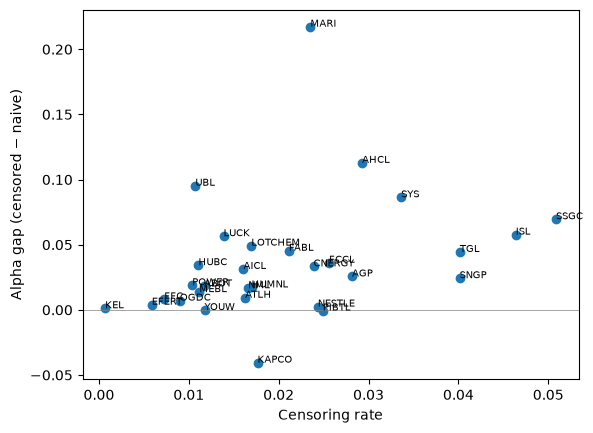

In [29]:
import matplotlib.pyplot as plt
plt.scatter(results_df['censoring_rate'], results_df['alpha_gap'])
for _, row in results_df.iterrows():
    plt.annotate(row['ticker'], (row['censoring_rate'], row['alpha_gap']), fontsize=7)
plt.xlabel('Censoring rate')
plt.ylabel('Alpha gap (censored − naive)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.show()

In [30]:
no_mari = results_df[results_df['ticker'] != 'MARI']
r_p2, p_p2 = pearsonr(no_mari['censoring_rate'], no_mari['alpha_gap'])
print(f"Pearson without MARI: r={r_p2:.3f} p={p_p2:.4f}")

Pearson without MARI: r=0.436 p=0.0180


In [1]:
import pandas as pd
panel = pd.read_parquet("data/panel.parquet")
summ = pd.read_csv("data/summary.csv")

# 1. Artefact check: eyeball the worst stock's floor-censored rows
worst = summ.sort_values("censor_rate_floor", ascending=False)["symbol"].iat[0]
print(summ.set_index("symbol").loc[worst, ["n","censor_rate_floor","censor_rate_pct","floor_share","zero_vol_share"]])
x = panel[(panel.symbol == worst) & panel.floor_binds & panel.censored]
display(x[["date","close","upper","lower","band","volume"]].head(15))

# 2. The real H1 view: within-stock, only stocks that have BOTH floor and pct days
g = panel.groupby(["symbol","floor_binds"])["censored"].mean().unstack()
both = g.dropna()
both.columns = ["pct_days", "floor_days"]
both["floor_lower"] = both["floor_days"] < both["pct_days"]
display(both)
print(f"{both['floor_lower'].sum()}/{len(both)} stocks censor less on floor days")

n                    146.000000
censor_rate_floor      0.571429
censor_rate_pct        0.098485
floor_share            0.095890
zero_vol_share         0.184932
Name: AGLNCPS, dtype: float64


,date,close,upper,lower,band,volume
25389,2024-04-29,6.59,6.59,4.59,1.0,5000
25390,2024-04-30,7.59,7.59,5.59,1.0,500
25391,2024-05-02,8.59,8.59,6.59,1.0,500
25392,2024-05-03,9.59,9.59,7.59,1.0,1000
25393,2024-05-06,10.59,10.59,8.59,1.0,500
25394,2024-05-07,11.59,11.59,9.59,1.0,500
25395,2024-05-08,12.59,12.59,10.59,1.0,2000
25396,2024-05-09,13.59,13.59,11.59,1.0,3000


,pct_days,floor_days,floor_lower
symbol,,,
786,0.081346,0.029326,True
AATM,0.127434,0.102041,True
ADAMS,0.065000,0.195122,False
ADOS,0.195726,0.272727,False
AGHA,0.017241,0.009174,True
AGIC,0.017493,0.125000,False
AGL,0.061856,0.018374,True
AGLNCPS,0.098485,0.571429,False


4/8 stocks censor less on floor days


In [2]:
import pandas as pd
from scipy.stats import binomtest, chi2_contingency

panel = pd.read_parquet("data/panel.parquet")
summ  = pd.read_csv("data/summary.csv")
uni   = pd.read_csv("data/universe.csv")

# --- filters ---
pref = set(uni.loc[uni["name"].str.contains("PREF", case=False, na=False), "symbol"])
pref |= {s for s in summ.symbol if s.endswith(("CPS", "PS"))}
print("pref-flagged:", sorted(pref & set(summ.symbol)))
keep = summ[~summ.symbol.isin(pref) & (summ.n >= 500) & (summ.zero_vol_share <= 0.20)]
print(f"{len(summ)} -> {len(keep)} after filters")

# --- H1 within-stock ---
pk = panel[panel.symbol.isin(keep.symbol) & ~panel.breach]
g = pk.groupby(["symbol", "floor_binds"])["censored"].mean().unstack().dropna()
g.columns = ["pct_days", "floor_days"]
k, n = int((g.floor_days < g.pct_days).sum()), len(g)
print(f"H1: {k}/{n} stocks censor less on floor days | sign test p = {binomtest(k, n).pvalue:.2e}")
print(f"median gap (floor - pct): {(g.floor_days - g.pct_days).median():.4f}")

# --- ISL replication ---
isl = pk[pk.symbol == "ISL"]
ct = pd.crosstab(isl.floor_binds, isl.censored)
print("\nISL:\n", ct, "\nchi2 p =", chi2_contingency(ct)[1])

pref-flagged: ['AGLNCPS', 'ASLCPS', 'ASLPS', 'CLCPS', 'DOLCPS', 'EPCLPS', 'HSMCPS', 'JVDCPS', 'MSOTPS', 'POWERPS', 'TCORPCPS']
652 -> 468 after filters
H1: 143/245 stocks censor less on floor days | sign test p = 1.05e-02
median gap (floor - pct): -0.0073

ISL:
 censored     False  True 
floor_binds              
False         2363    107 
chi2 p = 1.0


In [3]:
import glob
print("new:", panel.loc[panel.symbol=="ISL","close"].agg(["min","max"]).to_dict())
print(glob.glob("data/**/*ISL*", recursive=True))

new: {'min': 28.76, 'max': 165.4}
['data\\raw\\ISL', 'data\\raw\\ISL.parquet', 'data\\raw\\TISL.parquet']


In [4]:
ct = pd.crosstab(pk.floor_binds, pk.censored)
print(ct, "\npooled chi2 p =", chi2_contingency(ct)[1])
print(pk.groupby("floor_binds")["censored"].mean())

censored      False  True 
floor_binds               
False        585140  35579
True         229298   9418 
pooled chi2 p = 3.928178017641018e-243
floor_binds
False    0.057319
True     0.039453
Name: censored, dtype: float64


In [5]:
import pandas as pd
from scipy.stats import spearmanr, pearsonr, binomtest, wilcoxon

f = pd.read_csv("results/garch_fits.csv")
m = f[~f.at_boundary]
print(f"{len(f)} fits | {len(m)} after dropping boundary")

# H2a: is alpha higher once censoring is modelled?
k = int((m.alpha_gap > 0).sum())
print(f"\nlatent gap > 0: {k}/{len(m)} | sign p = {binomtest(k, len(m)).pvalue:.2e}"
      f" | Wilcoxon p = {wilcoxon(m.alpha_gap).pvalue:.2e}")
print(f"median gap  latent: {m.alpha_gap.median():.4f} | partial (preprint model): {m.alpha_gap_partial.median():.4f}")

# H2b: does the gap grow with censoring? (your original r=0.44 result)
for col in ["alpha_gap", "alpha_gap_partial"]:
    rs = spearmanr(m.censor_rate, m[col])
    print(f"{col:18s} Spearman r = {rs.statistic:.3f}, p = {rs.pvalue:.2e}")

# robustness: boundary fits included
rs = spearmanr(f.censor_rate, f.alpha_gap)
print(f"\nincl. boundary: Spearman r = {rs.statistic:.3f}, p = {rs.pvalue:.2e}")

# ISL, the preprint's single-stock case
print("\nISL:", f.loc[f.symbol=="ISL", ["alpha_n","alpha_c","alpha_l","censor_rate"]].round(3).to_dict("records"))

468 fits | 453 after dropping boundary

latent gap > 0: 442/453 | sign p = 3.22e-115 | Wilcoxon p = 8.65e-75
median gap  latent: 0.0310 | partial (preprint model): 0.0481
alpha_gap          Spearman r = 0.728, p = 4.44e-76
alpha_gap_partial  Spearman r = 0.853, p = 3.38e-129

incl. boundary: Spearman r = 0.713, p = 9.55e-74

ISL: [{'alpha_n': 0.126, 'alpha_c': 0.172, 'alpha_l': 0.168, 'censor_rate': 0.043}]


In [6]:
m = m.assign(rel_gap = m.alpha_gap / m.alpha_n)
print(f"median relative understatement: {m.rel_gap.median():.1%}")
print(m[["alpha_n","alpha_l","alpha_gap","rel_gap"]].describe().round(3))

median relative understatement: 21.8%
       alpha_n  alpha_l  alpha_gap  rel_gap
count  453.000  453.000    453.000  453.000
mean     0.155    0.202      0.047    0.300
std      0.054    0.089      0.054    0.410
min      0.049    0.056     -0.031   -0.157
25%      0.121    0.144      0.013    0.091
50%      0.145    0.187      0.031    0.218
75%      0.179    0.235      0.059    0.376
max      0.434    0.612      0.454    6.036


In [7]:
r = pd.read_csv("results/garch_fits_regime.csv")
r = r[~r.at_boundary].assign(rel_gap=lambda d: d.alpha_gap / d.alpha_n)
print(r.groupby("regime")[["censor_rate","alpha_gap","rel_gap"]].median().round(4))
print(r.groupby("regime").size())

# within-stock: stocks present in both the 5% and 10% windows
w = r.pivot_table(index="symbol", columns="regime", values="alpha_gap").dropna(subset=["5.0%","10.0%"])
k = int((w["5.0%"] > w["10.0%"]).sum())
print(f"\ngap larger under 5% than 10%: {k}/{len(w)} | sign p = {binomtest(k, len(w)).pvalue:.2e}")

        censor_rate  alpha_gap  rel_gap
regime                                 
10.0%        0.0236     0.0264   0.1400
5.0%         0.0632     0.0327   0.2238
7.5%         0.0267     0.0177   0.1274
regime
10.0%    406
5.0%     333
7.5%     374
dtype: int64

gap larger under 5% than 10%: 172/289 | sign p = 1.45e-03


In [8]:
import numpy as np
from scipy.stats import mannwhitneyu

panel = pd.read_parquet("data/panel.parquet")
win = {"5.0%": ("2016-01-01","2020-01-19"), "7.5%": ("2020-03-20","2024-05-26")}
fs = pd.concat([panel[(panel.date>=a)&(panel.date<=b)].groupby("symbol")["floor_binds"].mean().rename(k)
                for k,(a,b) in win.items()], axis=1).dropna()

grp = np.select([(fs["5.0%"]<0.1)&(fs["7.5%"]<0.1), (fs["5.0%"]>0.9)&(fs["7.5%"]>0.9)],
                ["treated","control"], "mixed")
fs = fs.assign(group=grp)

w = r.pivot_table(index="symbol", columns="regime", values=["censor_rate","alpha_gap"])
d = pd.DataFrame({
    "d_cens": w["censor_rate"]["7.5%"] - w["censor_rate"]["5.0%"],
    "d_gap":  w["alpha_gap"]["7.5%"]  - w["alpha_gap"]["5.0%"],
}).join(fs["group"]).dropna()
d = d[d.group != "mixed"]

print(d.groupby("group")[["d_cens","d_gap"]].median().round(4), "\n", d.group.value_counts())
for c in ["d_cens","d_gap"]:
    t, ctl = d.loc[d.group=="treated", c], d.loc[d.group=="control", c]
    print(f"{c}: treated vs control, Mann-Whitney p = {mannwhitneyu(t, ctl, alternative='less').pvalue:.3e}")

         d_cens   d_gap
group                  
control -0.0013 -0.0000
treated -0.0425 -0.0188 
 group
treated    169
control     51
Name: count, dtype: int64
d_cens: treated vs control, Mann-Whitney p = 2.519e-17
d_gap: treated vs control, Mann-Whitney p = 2.832e-07


In [9]:
from joblib import Parallel, delayed
from scipy.stats import mannwhitneyu
import numpy as np
from src.fit_garch import fit_one, filtered_symbols

syms = set(filtered_symbols())

def window_fits(a, b, min_obs=350):
    sub = panel[(panel.date >= a) & (panel.date <= b) & panel.symbol.isin(syms)]
    groups = [(s, g) for s, g in sub.groupby("symbol") if len(g) >= min_obs]
    out = pd.DataFrame(Parallel(n_jobs=-2)(delayed(fit_one)(s, g) for s, g in groups))
    out = out[out.error.fillna("") == ""]
    out = out[~out.at_boundary.astype(bool)].set_index("symbol")
    return out[["censor_rate", "alpha_gap"]].join(sub.groupby("symbol")["floor_binds"].mean())

def did(name, pre, post):
    A, B = window_fits(*pre), window_fits(*post)
    d = (B[["censor_rate", "alpha_gap"]] - A[["censor_rate", "alpha_gap"]]).dropna()
    fs = pd.concat([A.floor_binds.rename("a"), B.floor_binds.rename("b")], axis=1).dropna()
    grp = pd.Series(np.select([(fs.a < .1) & (fs.b < .1), (fs.a > .9) & (fs.b > .9)],
                              ["treated", "control"], "mixed"), index=fs.index)
    d = d.join(grp.rename("group")).query("group != 'mixed'").dropna()
    print(f"\n=== {name} ===")
    print(d.groupby("group").median().round(4), "\n", d.group.value_counts().to_dict())
    for c in ["censor_rate", "alpha_gap"]:
        t, k = d.loc[d.group == "treated", c], d.loc[d.group == "control", c]
        print(f"Δ{c}: Mann-Whitney p = {mannwhitneyu(t, k).pvalue:.3e}")

did("PLACEBO mid-2018 (no rule change)", ("2016-09-27", "2018-05-31"), ("2018-06-01", "2020-01-19"))
did("2024 change 7.5% → 10%", ("2020-03-20", "2024-05-26"), ("2024-07-22", "2026-12-31"))


=== PLACEBO mid-2018 (no rule change) ===
         censor_rate  alpha_gap
group                          
control      -0.0084    -0.0021
treated       0.0116     0.0058 
 {'treated': 94, 'control': 46}
Δcensor_rate: Mann-Whitney p = 9.389e-08
Δalpha_gap: Mann-Whitney p = 7.419e-03

=== 2024 change 7.5% → 10% ===
         censor_rate  alpha_gap
group                          
control       0.0109      0.012
treated      -0.0082     -0.000 
 {'treated': 208, 'control': 15}
Δcensor_rate: Mann-Whitney p = 6.004e-07
Δalpha_gap: Mann-Whitney p = 1.021e-01
